In [ ]:
from SPARZ import SPARZIP, SPARUNZIP
import os
from tqdm import tqdm


In [ ]:
# Paths for input files
path1 = '/Users/laurabreimann/Desktop/DNA-PAINT_raw/RawFramesforTraining_P5-IS_20pM.tif'
#path2 = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/sequence-as-stack-MT0.N1.HD-BP-250.tif'

stem= 'PAINT'

# Define ranges for grid search
kernel_sizes =  range(11, 24, 4) #  5, 7, 9, 11 
rel_thresholds = [0.05, 0.25, 0.45, 0.65]  # 0.35, 0.45, 0.55, 0.65
compression_levels = [0, 1, 2, 3]  # 0, 1, 2, 3


# Extract base filenames without extension
base_filename1 = os.path.splitext(os.path.basename(path1))[0]
#base_filename2 = os.path.splitext(os.path.basename(path2))[0]


# Total number of iterations for progress bar
total_iterations = len(kernel_sizes) * len(rel_thresholds) * len(compression_levels)

In [ ]:
# Iterate over all combinations of parameters
with tqdm(total=total_iterations, desc="Grid Search Progress", unit="iteration") as pbar: # Initialize tqdm progress bar
    for kernel_size in kernel_sizes:
        for rel_thresh in rel_thresholds:
            for compression_level in compression_levels:
                # Create output paths based on parameters
                output_path = f'/Users/laurabreimann/Desktop/DNA-PAINT_2/sparz_k{kernel_size}_rt{int(rel_thresh*100)}_lev{compression_level}'
                uncompressed_path = os.path.join(output_path, 'uncompressed')
                os.makedirs(uncompressed_path, exist_ok=True)

                # SPARZIP
                z = SPARZIP(path1, stem, output_path, relative_threshold = rel_thresh, kernel_size =kernel_size)
                z.run(codec='x265', compression_level=compression_level)

                # Output files for SPARUNZIP
                path_sparse_bp1 = os.path.join(output_path, f'{base_filename1}.npz')
                #path_sparse_bp2 = os.path.join(output_path, f'{base_filename2}.npz')
                mp4_1 = os.path.join(output_path, f'{base_filename1}_compression_level_{compression_level}.mp4')
                #mp4_2 = os.path.join(output_path, f'{base_filename2}_compression_level_{compression_level}.mp4')

                # SPARUNZIP
                u= SPARUNZIP(path_sparse_bp1= path_sparse_bp1,
                            path_encoded_bp1= mp4_1,
                            stem= stem,
                            output_path= uncompressed_path,
                            #path_sparse_bp2= path_sparse_bp2,
                            #path_encoded_bp2= mp4_2,
                            use_roi = True,
                            chunk_size = 10) 
                u.run()

                # Update progress bar
                pbar.update(1)



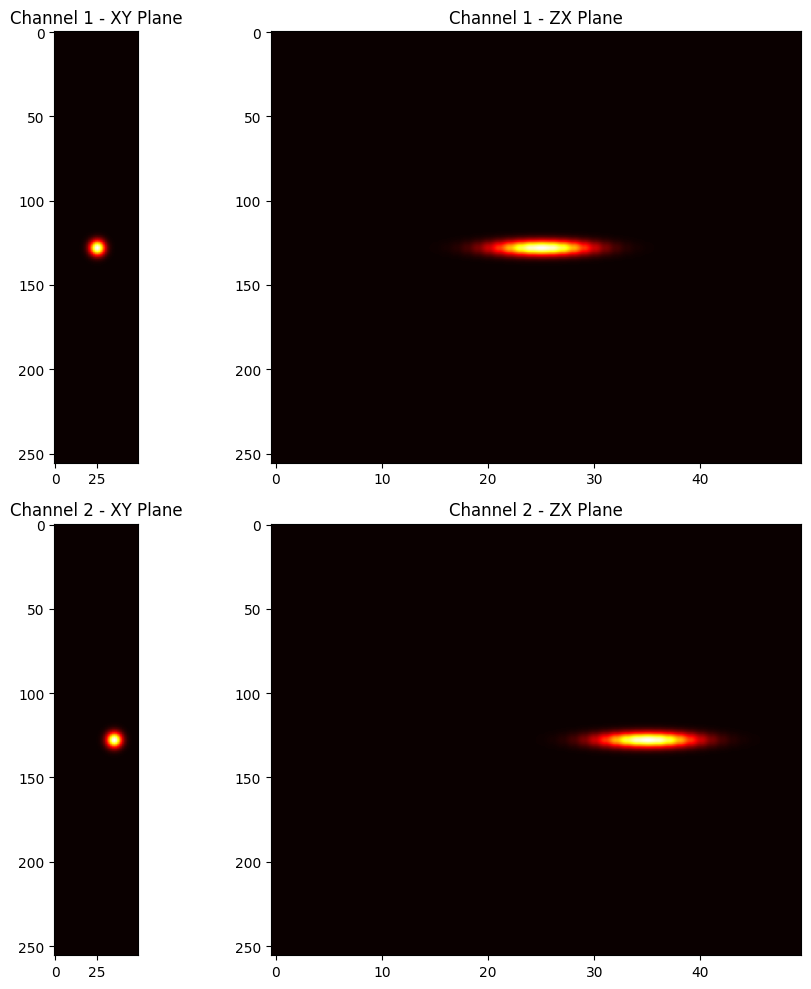

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def generate_3d_psf(image_size, center, sigma):
    """
    Generate a 3D Gaussian point spread function (PSF).
    
    Parameters:
    - image_size: tuple of (depth, height, width) of the output image.
    - center: tuple of (z, y, x) coordinates of the PSF center.
    - sigma: standard deviation of the Gaussian.
    
    Returns:
    - psf: 3D array representing the PSF.
    """
    z = np.linspace(0, image_size[0] - 1, image_size[0])
    y = np.linspace(0, image_size[1] - 1, image_size[1])
    x = np.linspace(0, image_size[2] - 1, image_size[2])
    x, y, z = np.meshgrid(x, y, z, indexing='ij')
    psf = np.exp(-((x - center[2])**2 + (y - center[1])**2 + (z - center[0])**2) / (2 * sigma**2))
    return psf

# Parameters
image_size_3d = (50, 256, 256)
center_3d = (25, 128, 128)
sigma = 3
z_focus1 = 0
z_focus2 = 10  # Shift for the second focal plane

# Generate 3D PSF images for two different focal planes
psf1_3d = generate_3d_psf(image_size_3d, (center_3d[0] + z_focus1, center_3d[1], center_3d[2]), sigma)
psf2_3d = generate_3d_psf(image_size_3d, (center_3d[0] + z_focus2, center_3d[1], center_3d[2]), sigma)

# Apply Gaussian filter to simulate the optical system blur
psf1_3d = gaussian_filter(psf1_3d, sigma=1)
psf2_3d = gaussian_filter(psf2_3d, sigma=1)

# Create XY images by taking a central slice
xy_slice1 = psf1_3d[25, :, :]
xy_slice2 = psf2_3d[25, :, :]

# Create ZX images by summing over the Y axis
zx_slice1 = np.sum(psf1_3d, axis=1)
zx_slice2 = np.sum(psf2_3d, axis=1)

# Plot the results
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0, 0].imshow(xy_slice1, cmap='hot')
axs[0, 0].set_title('Channel 1 - XY Plane')

axs[0, 1].imshow(zx_slice1, cmap='hot', aspect='auto')
axs[0, 1].set_title('Channel 1 - ZX Plane')

axs[1, 0].imshow(xy_slice2, cmap='hot')
axs[1, 0].set_title('Channel 2 - XY Plane')

axs[1, 1].imshow(zx_slice2, cmap='hot', aspect='auto')
axs[1, 1].set_title('Channel 2 - ZX Plane')

plt.tight_layout()
plt.show()


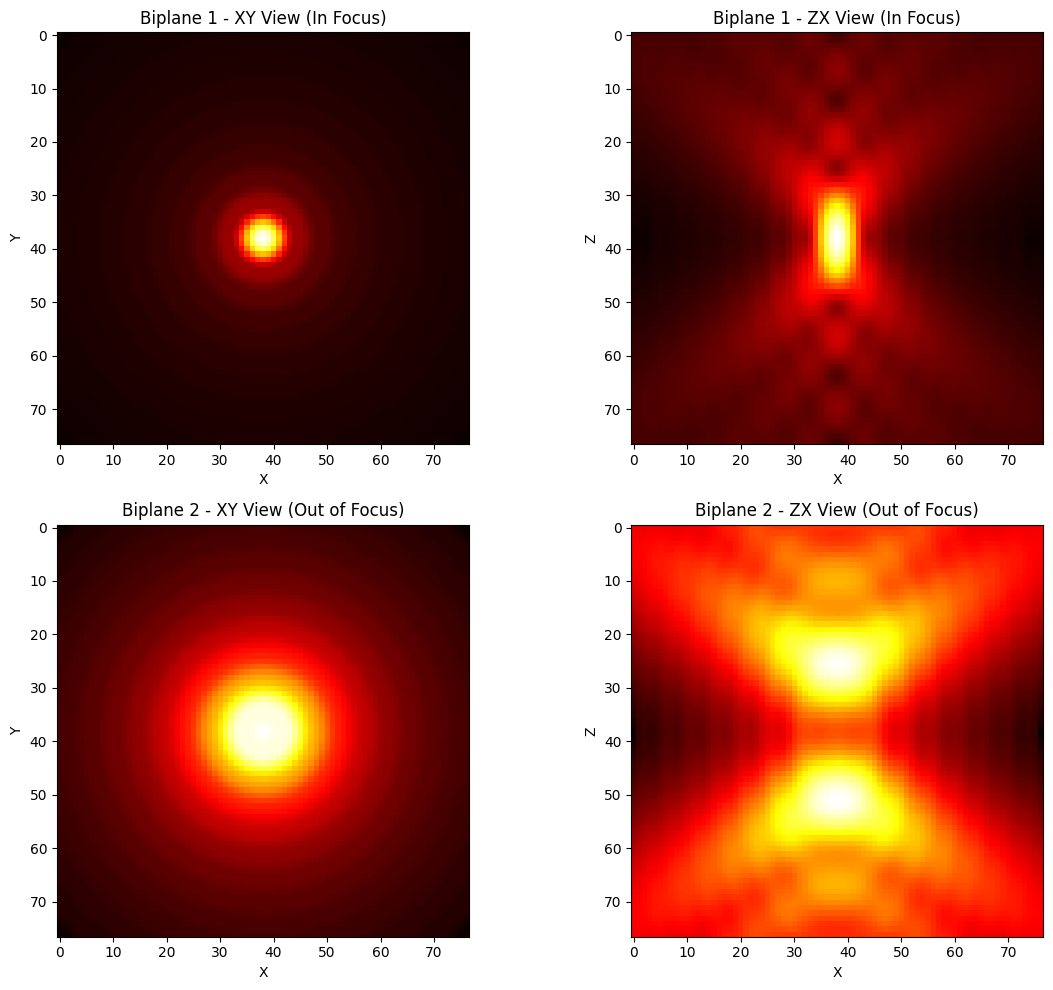

In [41]:
import psfmodels as psfm
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

# Generate centered PSF with a point source at `pz` microns from coverslip
# In-focus PSF
psf_in_focus = psfm.make_psf(77, 77, dxy=0.05, dz=0.05, pz=0)

# Out-of-focus PSF
psf_out_of_focus = psfm.make_psf(77, 77, dxy=0.05, dz=0.05, pz=0.15)  # Adjust pz for out-of-focus condition

# Plot the results
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# XY View - In Focus
axs[0, 0].imshow(psf_in_focus[38], norm=PowerNorm(gamma=0.4), cmap='hot')
axs[0, 0].set_title('Biplane 1 - XY View (In Focus)')
axs[0, 0].set_xlabel('X')
axs[0, 0].set_ylabel('Y')

# ZX View - In Focus
axs[0, 1].imshow(psf_in_focus[:, 38], norm=PowerNorm(gamma=0.4), cmap='hot')
axs[0, 1].set_title('Biplane 1 - ZX View (In Focus)')
axs[0, 1].set_xlabel('X')
axs[0, 1].set_ylabel('Z')

# XY View - Out of Focus
axs[1, 0].imshow(psf_out_of_focus[48], norm=PowerNorm(gamma=0.4), cmap='hot')
axs[1, 0].set_title('Biplane 2 - XY View (Out of Focus)')
axs[1, 0].set_xlabel('X')
axs[1, 0].set_ylabel('Y')

# ZX View - Out of Focus
axs[1, 1].imshow(psf_out_of_focus[:, 48], norm=PowerNorm(gamma=0.4), cmap='hot')
axs[1, 1].set_title('Biplane 2 - ZX View (Out of Focus)')
axs[1, 1].set_xlabel('X')
axs[1, 1].set_ylabel('Z')

plt.tight_layout()
plt.show()


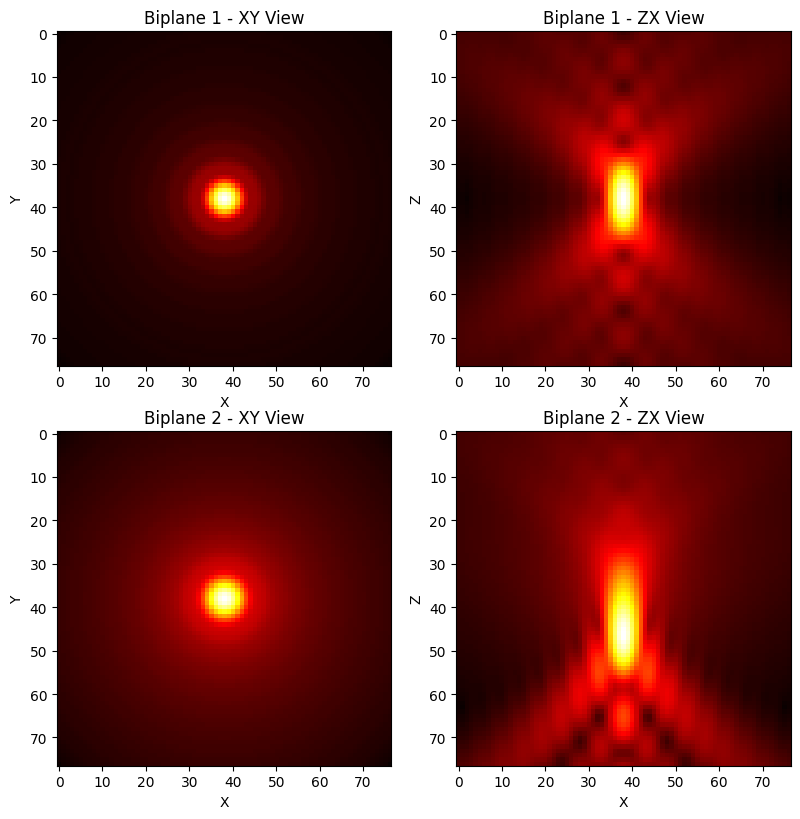

In [53]:
import psfmodels as psfm
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

# Generate centered PSF with a point source at `pz` microns from coverslip
# In-focus PSF
psf_in_focus = psfm.make_psf(77, 77, dxy=0.05, dz=0.05, pz=0)

# Out-of-focus PSF
psf_out_of_focus = psfm.make_psf(77, 77, dxy=0.05, dz=0.05, pz=10)  # Adjust pz for out-of-focus condition

# Plot the results
fig, axs = plt.subplots(2, 2, figsize=(8, 8))

# XY View - In Focus
axs[0, 0].imshow(psf_in_focus[38], norm=PowerNorm(gamma=0.4), cmap='hot')
axs[0, 0].set_title('Biplane 1 - XY View')
axs[0, 0].set_xlabel('X')
axs[0, 0].set_ylabel('Y')

# ZX View - In Focus
axs[0, 1].imshow(psf_in_focus[:, 38], norm=PowerNorm(gamma=0.4), cmap='hot')
axs[0, 1].set_title('Biplane 1 - ZX View')
axs[0, 1].set_xlabel('X')
axs[0, 1].set_ylabel('Z')

# XY View - Out of Focus
axs[1, 0].imshow(psf_out_of_focus[38], norm=PowerNorm(gamma=0.4), cmap='hot')
axs[1, 0].set_title('Biplane 2 - XY View')
axs[1, 0].set_xlabel('X')
axs[1, 0].set_ylabel('Y')

# ZX View - Out of Focus
axs[1, 1].imshow(psf_out_of_focus[:, 38], norm=PowerNorm(gamma=0.4), cmap='hot')
axs[1, 1].set_title('Biplane 2 - ZX View')
axs[1, 1].set_xlabel('X')
axs[1, 1].set_ylabel('Z')

plt.tight_layout(pad=.001)
plt.show()
